In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

c:\Users\atulm\Documents\Learning_LangGraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:

def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}


def generate_explanation(state: JokeState):

    prompt = f"""Write a short explanation for the joke 
    Topic - {state["topic"]} 
    Joke - {state["joke"]}
    """
    
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [6]:

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

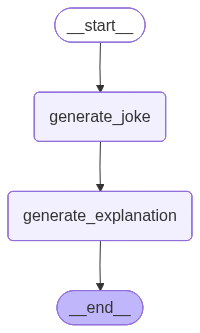

In [7]:
workflow

In [8]:

config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally get a *slice* of the corporate pie! 🍕😄',
 'explanation': '**Explanation**\n\nThe joke hinges on a series of puns that link pizza terminology with common expressions about work and money:\n\n- **“Dough”** – In baking, dough is the raw batter that becomes pizza crust. In slang, “dough” also means money. So the pizza wants to “earn some dough” like a person earns a salary.  \n- **“Slice”** – A slice is a piece of pizza. In business lingo, getting a “slice of the pie” means receiving a share of profits or opportunities.  \n- **“Corporate pie”** – The phrase “the corporate pie” is a metaphor for the overall market or the pool of business opportunities. By saying the pizza wants a “slice of the corporate pie,” the joke imagines the pizza trying to claim its own portion of that market.\n\nPutting it together, the pizza’s “job application” is funny because it treats everyday pi

In [9]:

workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally get a *slice* of the corporate pie! 🍕😄', 'explanation': '**Explanation**\n\nThe joke hinges on a series of puns that link pizza terminology with common expressions about work and money:\n\n- **“Dough”** – In baking, dough is the raw batter that becomes pizza crust. In slang, “dough” also means money. So the pizza wants to “earn some dough” like a person earns a salary.  \n- **“Slice”** – A slice is a piece of pizza. In business lingo, getting a “slice of the pie” means receiving a share of profits or opportunities.  \n- **“Corporate pie”** – The phrase “the corporate pie” is a metaphor for the overall market or the pool of business opportunities. By saying the pizza wants a “slice of the corporate pie,” the joke imagines the pizza trying to claim its own portion of that market.\n\nPutting it together, the pizza’s “job application” is funny because it

In [10]:
workflow.get_state_history(config1)

<generator object Pregel.get_state_history at 0x000001D655DB2650>

In [11]:
for checkpoint in workflow.get_state_history(config1):
    print(checkpoint)
    print('\n\n ===============================================================\n\n')

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally get a *slice* of the corporate pie! 🍕😄', 'explanation': '**Explanation**\n\nThe joke hinges on a series of puns that link pizza terminology with common expressions about work and money:\n\n- **“Dough”** – In baking, dough is the raw batter that becomes pizza crust. In slang, “dough” also means money. So the pizza wants to “earn some dough” like a person earns a salary.  \n- **“Slice”** – A slice is a piece of pizza. In business lingo, getting a “slice of the pie” means receiving a share of profits or opportunities.  \n- **“Corporate pie”** – The phrase “the corporate pie” is a metaphor for the overall market or the pool of business opportunities. By saying the pizza wants a “slice of the corporate pie,” the joke imagines the pizza trying to claim its own portion of that market.\n\nPutting it together, the pizza’s “job application” is funny because it

### Thread 2 Demo

In [12]:

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta* way to the top! 🍝😄',
 'explanation': '**Explanation**\n\nThe joke plays on a pun between the word **“pasta”** (the food category that includes spaghetti) and the phrase **“passed a”** (as in “passed a way to the top”).  \n\n- In the setup, a spaghetti strand is imagined as an employee who could earn a promotion.  \n- The punchline says it “*pasta* way to the top.” When spoken, “pasta” sounds like “passed a,” so the line can be heard as “passed a way to the top,” meaning it succeeded in moving upward in the company.  \n\nThe humor comes from swapping the ordinary verb “passed” with the food‑related word “pasta,” creating a goofy, food‑themed twist on a typical workplace expression. The accompanying pasta emoji reinforces the theme.'}

In [14]:
for checkpoint in workflow.get_state_history(config2):
    print(checkpoint)
    print('\n\n ===============================================================\n\n')

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta* way to the top! 🍝😄', 'explanation': '**Explanation**\n\nThe joke plays on a pun between the word **“pasta”** (the food category that includes spaghetti) and the phrase **“passed a”** (as in “passed a way to the top”).  \n\n- In the setup, a spaghetti strand is imagined as an employee who could earn a promotion.  \n- The punchline says it “*pasta* way to the top.” When spoken, “pasta” sounds like “passed a,” so the line can be heard as “passed a way to the top,” meaning it succeeded in moving upward in the company.  \n\nThe humor comes from swapping the ordinary verb “passed” with the food‑related word “pasta,” creating a goofy, food‑themed twist on a typical workplace expression. The accompanying pasta emoji reinforces the theme.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1418a8-3919-66e7-8002-1c24d0d0ae72'}}, metadata={'sour

## Time travel

In [19]:
workflow.get_state(
    {"configurable": 
     {
    "thread_id": "2",
    "checkpoint_id": "1f1418a8-25f2-624b-8000-59b57c3cc456"
    }
    })

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1418a8-25f2-624b-8000-59b57c3cc456'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-26T16:10:57.376109+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1418a8-25f2-624a-bfff-550ab6e487ac'}}, tasks=(PregelTask(id='580d2b87-31e3-2233-c1bc-5011fd12099a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta* way to the top! 🍝😄'}),), interrupts=())

In [20]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f1418a8-25f2-624b-8000-59b57c3cc456"}})


{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?  \n\nBecause it knew how to *pasta* the competition and always *rolled* with the punches! 🍝😄',
 'explanation': '**Explanation**\n\nThe humor comes from two puns that replace ordinary words with pasta‑related ones:\n\n1. **“pasta the competition”** – sounds like “passed the competition.”  \n   Using *pasta* (the food) instead of *passed* creates a playful word swap that fits the spaghetti theme.\n\n2. **“rolled with the punches”** – a common idiom meaning to adapt smoothly to challenges.  \n   Here *rolled* also alludes to how long strands of spaghetti are rolled or twirled, reinforcing the noodle imagery.\n\nTogether, the punchline suggests that the spaghetti earned a promotion because it “passed” (out‑performed) its rivals and “rolled” (handled) difficulties—both literal and figurative references to pasta. The emoji 🍝 and the smiling face add a light, food‑themed tone.'}

In [24]:
for checkpoint in workflow.get_state_history({"configurable": {"thread_id": "2"}}):
    print(checkpoint)
    print('\n\n ===============================================================\n\n')

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?  \n\nBecause it knew how to *pasta* the competition and always *rolled* with the punches! 🍝😄', 'explanation': '**Explanation**\n\nThe humor comes from two puns that replace ordinary words with pasta‑related ones:\n\n1. **“pasta the competition”** – sounds like “passed the competition.”  \n   Using *pasta* (the food) instead of *passed* creates a playful word swap that fits the spaghetti theme.\n\n2. **“rolled with the punches”** – a common idiom meaning to adapt smoothly to challenges.  \n   Here *rolled* also alludes to how long strands of spaghetti are rolled or twirled, reinforcing the noodle imagery.\n\nTogether, the punchline suggests that the spaghetti earned a promotion because it “passed” (out‑performed) its rivals and “rolled” (handled) difficulties—both literal and figurative references to pasta. The emoji 🍝 and the smiling face add a light, food‑themed tone.'}, next=(), config={'configura

## Updating State

In [26]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1418a4-7dd9-68f7-8000-523bd528ee8b", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1418fe-be4b-6100-8001-54f7cd67a162'}}

In [28]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1418fe-be4b-6100-8001-54f7cd67a162"}})

StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1418fe-be4b-6100-8001-54f7cd67a162'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-26T16:49:41.895808+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1418a4-7dd9-68f7-8000-523bd528ee8b'}}, tasks=(PregelTask(id='b83499c1-b0bd-9b9b-e4fc-43145ca347c6', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [30]:
list(workflow.get_state_history({"configurable": {"thread_id": "1"}}))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1418fe-be4b-6100-8001-54f7cd67a162'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-26T16:49:41.895808+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1418a4-7dd9-68f7-8000-523bd528ee8b'}}, tasks=(PregelTask(id='b83499c1-b0bd-9b9b-e4fc-43145ca347c6', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally get a *slice* of the corporate pie! 🍕😄', 'explanation': '**Explanation**\n\nThe joke hinges on a series of puns that link pizza terminology with common expressions about work and money:\n\n- **“Dough”** – In baking, dough is the raw batter t

In [32]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1418fe-be4b-6100-8001-54f7cd67a162"}})


{'topic': 'samosa',
 'joke': 'Why did the samosa apply for a job?  \n\nBecause it heard the position was *filled* with “crunch” time and lots of *stuff* to do!',
 'explanation': '**Explanation**\n\nThe humor comes from a play on words that links the nature of a samosa—a fried pastry that is *filled* with a savory mixture—to typical workplace jargon.\n\n- **“Filled”** – A samosa is literally packed with a stuffing (potatoes, peas, spices, etc.). In a job posting, “filled” also means the position is occupied or that the role has a lot of responsibilities.\n\n- **“Crunch time”** – In a kitchen, a samosa gets its characteristic *crunch* when it’s fried. In business, “crunch time” refers to a period of intense work or a looming deadline.\n\n- **“Stuff to do”** – The interior of a samosa is called “stuffing.” Saying a job has a lot of “stuff to do” is a common way to describe a busy workload.\n\nBy conflating the culinary attributes of a samosa with corporate buzzwords, the joke creates a si

In [33]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa apply for a job?  \n\nBecause it heard the position was *filled* with “crunch” time and lots of *stuff* to do!', 'explanation': '**Explanation**\n\nThe humor comes from a play on words that links the nature of a samosa—a fried pastry that is *filled* with a savory mixture—to typical workplace jargon.\n\n- **“Filled”** – A samosa is literally packed with a stuffing (potatoes, peas, spices, etc.). In a job posting, “filled” also means the position is occupied or that the role has a lot of responsibilities.\n\n- **“Crunch time”** – In a kitchen, a samosa gets its characteristic *crunch* when it’s fried. In business, “crunch time” refers to a period of intense work or a looming deadline.\n\n- **“Stuff to do”** – The interior of a samosa is called “stuffing.” Saying a job has a lot of “stuff to do” is a common way to describe a busy workload.\n\nBy conflating the culinary attributes of a samosa with corporate buzzwords, t